In [9]:
import glob
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

In [ ]:
def mosaic_fits(input_files, output_wcs, output_shape, output_file):
    output_data = np.zeros(output_shape, dtype=np.float32)
    ny_total, nx_total = output_shape[1], output_shape[2]
    output_wcs_2d = output_wcs.celestial
    for file in input_files:
        print("处理:", file)
        hdul = fits.open(file)
        header = hdul[0].header
        wcs = WCS(header)
        wcs_2d = wcs.celestial

        nx = header["NAXIS1"]
        ny = header["NAXIS2"]
        data = hdul[0].data  # 已经转换为 float32 的数据
        # print("data的数据格式", data.dtype, "shape", data.shape)

        # 输入图片四角 -> 世界 -> 输出最终图像中的像素

        in_corners = np.array(
            [[0, 0], [nx - 1, 0], [0, ny - 1], [nx - 1, ny - 1]]
        )  # 输入图像的四个角的像素坐标
        ra1, dec1 = wcs_2d.wcs_pix2world(
            in_corners[:, 0], in_corners[:, 1], 0
        )  # 输入图像的四个角的世界坐标
        ox, oy = output_wcs_2d.wcs_world2pix(ra1, dec1, 0)  # 输入图像的四个角在输出图像中的像素坐标
        # print("输入图像的四个角的像素坐标:\n", in_corners)
        # print("输入图像的四个角的世界坐标:", ra1, dec1)
        # print("输入图像的四个角在输出图像中的像素坐标:", ox, oy)

        # 输出像素坐标取整，算输出 bounding box

        x0 = np.floor(np.min(ox))
        x1 = np.ceil(np.max(ox))
        y0 = np.floor(np.min(oy))
        y1 = np.ceil(np.max(oy))
        # print(f"对应输出像素 bounding box: [({x0}, {y0}), ({x1}, {y1})]")

        # 裁剪到输出范围

        x0c = max(0, x0)
        y0c = max(0, y0)
        x1c = min(nx_total - 1, x1)
        y1c = min(ny_total - 1, y1)

        if x0c > x1c or y0c > y1c:
            print("  -> 与目标区域无交集，跳过")

        # print(f"裁剪后的输出 bounding box: [({x0c}, {y0c}), ({x1c}, {y1c})]")

        # 输出 bounding box 四角 -> 世界 -> 输入像素，得到输入切片

        out_corners = np.array([[x0c, y0c], [x1c, y0c], [x0c, y1c], [x1c, y1c]])  # 裁剪后，输入图像的四个角在输出图像中的像素坐标
        ra2, dec2 = output_wcs_2d.wcs_pix2world(out_corners[:, 0], out_corners[:, 1], 0)  # 裁剪后，四个角的世界坐标
        ix, iy = wcs_2d.wcs_world2pix(ra2, dec2, 0)  # 裁剪后，四个角的世界坐标在输入图像中的像素坐标
        # print("裁剪后，输入图像的四个角在输出图像中的像素坐标:\n", out_corners)
        # print("裁剪后，四个角的世界坐标:", ra2, dec2)
        # print("裁剪后，四个角的世界坐标在输入图像中的像素坐标:", ix, iy)

        # 输入像素坐标取整，算输入 bounding box

        ix0 = np.floor(np.min(ix))
        ix1 = np.ceil(np.max(ix))
        iy0 = np.floor(np.min(iy))
        iy1 = np.ceil(np.max(iy))

        # print(f"对应输入像素 bounding box: [({ix0}, {iy0}), ({ix1}, {iy1})]")

        # 裁剪到输入范围

        ix0c = max(0, ix0)
        iy0c = max(0, iy0)
        ix1c = min(nx - 1, ix1)
        iy1c = min(ny - 1, iy1)

        # print(f"裁剪后的输入 bounding box: [({ix0c}, {iy0c}), ({ix1c}, {iy1c})]")

        # 用裁剪后的输入角点反算输出，确保尺寸一致（取 round 对齐到整数格）

        in_corners2 = np.array([[ix0c, iy0c], [ix1c, iy0c], [ix0c, iy1c], [ix1c, iy1c]])
        ra3, dec3 = wcs_2d.wcs_pix2world(in_corners2[:, 0], in_corners2[:, 1], 0)
        ox2, oy2 = output_wcs_2d.wcs_world2pix(ra3, dec3, 0)
        # print("裁剪后，四个角的世界坐标在输入图像中的像素坐标:\n", in_corners2)
        # print("反算出世界坐标，应该与 ra2, dec2 一致:", ra3, dec3)
        # print("反算出在输出图像中的像素坐标，应该与 x0c, x1c, y0c, y1c 一致:", ox2, oy2)

        # 输出像素坐标取整，算输出 bounding box

        x0o = np.round(np.min(ox2))
        x1o = np.round(np.max(ox2))
        y0o = np.round(np.min(oy2))
        y1o = np.round(np.max(oy2))
        # # print(f"对应输出像素 bounding box: [({x0o}, {y0o}), ({x1o}, {y1o})]")

        # 裁剪到输出范围

        x0_final = max(0, x0o)
        y0_final = max(0, y0o)
        x1_final = min(nx_total - 1, x1o)
        y1_final = min(ny_total - 1, y1o)
        # print(f"裁剪后的输出 bounding box: [({x0_final}, {y0_final}), ({x1_final}, {y1_final})]")

        # 裁剪到输出范围后，计算输入输出切片，并检查尺寸一致性
        # 在输出图像中的切片
        xs_out = slice(x0_final, x1_final + 1)
        ys_out = slice(y0_final, y1_final + 1)

        # 在输入图像中的切片
        xs_in = slice(ix0c, ix0c + (xs_out.stop - xs_out.start))
        ys_in = slice(iy0c, iy0c + (ys_out.stop - ys_out.start))

        if (xs_out.stop - xs_out.start) != (xs_in.stop - xs_in.start) or (
            ys_out.stop - ys_out.start
        ) != (ys_in.stop - ys_in.start):
            raise RuntimeError(f"切片尺寸不一致: {file}")

        # 最终切片信息
        # 索引需要转为 int 格式
        xs_out = slice(int(xs_out.start), int(xs_out.stop))
        ys_out = slice(int(ys_out.start), int(ys_out.stop))
        xs_in = slice(int(xs_in.start), int(xs_in.stop))
        ys_in = slice(int(ys_in.start), int(ys_in.stop))

        # print(f"最终在输出图像中的切片: {xs_out}, {ys_out}")
        # print(f"最终在输入图像中的切片: {xs_in}, {ys_in}")

        # 将输入数据累加到输出图像对应位置
        # print(f"最终输出切片 (y,x): {ys_out}, {xs_out}")
        # print(f"对应输入切片 (y,x): {ys_in}, {xs_in}")
        output_data[:, ys_out, xs_out] += data[:, ys_in, xs_in]

    # 写入输出 FITS
    out_header = output_wcs.to_header()
    out_header["NAXIS"] = 3
    out_header["NAXIS1"] = output_shape[2]
    out_header["NAXIS2"] = output_shape[1]
    out_header["NAXIS3"] = output_shape[0]
    out_header["BUNIT"] = "K"
    fits.writeto(output_file, output_data, header=out_header, overwrite=True)
    print("输出完成:", output_file)

In [12]:
fits_file_list = sorted(glob.glob('./*_N.fits'))
fits_file_list

['./GALFA_HI_RA+DEC_012.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_012.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_020.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_020.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_028.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_028.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_036.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_036.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_044.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_044.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_052.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_052.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_060.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_060.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_068.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_068.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_076.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_076.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_084.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_084.00+34.35_N.fits',
 './GALFA_HI_RA+DEC_092.00+26.35_N.fits',
 './GALFA_HI_RA+DEC_092.00+34.35_N.fits']

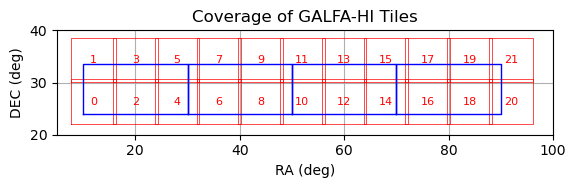

In [29]:
# 绘制每个图的覆盖图

x_start = [7.741658, 15.741658, 23.741658, 31.741658, 39.741658, 47.741658, 55.741658, 63.741658, 71.741658, 79.741658, 87.741658]
x_end = [16.258342, 24.258342, 32.258342, 40.258342, 48.258342, 56.258342, 64.258342, 72.258342, 80.258342, 88.258342, 96.258342]

x_output_start = [10, 30, 50, 70]
x_output_end = [30, 50, 70, 90]

import matplotlib.pyplot as plt

plt.figure()
# 每个方形取横坐标为 x_start[i] 到 x_end[i]，纵坐标交替取 22.091658 deg - 30.608342 deg 和 30.091658 deg - 38.608342 deg
# 并标注编号顺序，按x和y从小到大排列，写在方形的中间
for i in range(len(x_start)):
    plt.plot([x_start[i], x_end[i], x_end[i], x_start[i], x_start[i]], [22.091658, 22.091658, 30.608342, 30.608342, 22.091658], 'r-', linewidth=0.5)
    plt.plot([x_start[i], x_end[i], x_end[i], x_start[i], x_start[i]], [30.091658, 30.091658, 38.608342, 38.608342, 30.091658], 'r-', linewidth=0.5)
    plt.text((x_start[i] + x_end[i]) / 2, 26.35, str(i*2), color='r', fontsize=8, ha='center', va='center')
    plt.text((x_start[i] + x_end[i]) / 2, 34.35, str(i*2+1), color='r', fontsize=8, ha='center', va='center')
# 每个方形取横坐标为 x_output_start[i] 到 x_output_end[i]，纵坐标取 24 deg - 33.5 deg
for i in range(len(x_output_start)):
    plt.plot([x_output_start[i], x_output_end[i], x_output_end[i], x_output_start[i], x_output_start[i]], [24, 24, 33.5, 33.5, 24], 'b-', linewidth=1)
plt.xlabel('RA (deg)')
plt.ylabel('DEC (deg)')
plt.title('Coverage of GALFA-HI Tiles')
plt.xlim(5, 100)
plt.ylim(20, 40)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()
plt.show()

In [ ]:
input_files_list = [fits_file_list[0:6], fits_file_list[4:12], fits_file_list[10:16], fits_file_list[14:22]]
output_file_list = ["./Combined/GALFA_RA10_30_DEC24_33.fits", "./Combined/GALFA_RA30_50_DEC24_33.fits", "./Combined/GALFA_RA50_70_DEC24_33.fits", "./Combined/GALFA_RA70_90_DEC24_33.fits"]

for i, input_files in enumerate(input_files_list):
    print(f"处理第 {i} 组文件: {input_files}")

    ra_min, ra_max = x_output_start[i], x_output_end[i]
    dec_min, dec_max = 24.0, 33.5

    output_file = output_file_list[i]

    # 读取参考 header/WCS
    with fits.open(input_files[0], memmap=True, do_not_scale_image_data=True) as hdul0:
        header0 = hdul0[0].header
        wcs0 = WCS(header0)

    NAXIS3 = header0["NAXIS3"]
    BLANK = header0["BLANK"]
    CDELT1 = header0["CDELT1"]
    CDELT2 = header0["CDELT2"]

    nx_total = int(np.ceil((ra_max - ra_min) / abs(CDELT1)))
    ny_total = int(np.ceil((dec_max - dec_min) / abs(CDELT2)))
    output_shape = (NAXIS3, ny_total, nx_total)  # (v, y, x)

    # 构造输出WCS（与源一致，只锚定到目标范围）
    output_wcs = wcs0.deepcopy()
    output_wcs.wcs.crpix[0] = 1.0
    output_wcs.wcs.crpix[1] = 1.0
    output_wcs.wcs.crval[0] = ra_max
    output_wcs.wcs.crval[1] = dec_min
    output_wcs.wcs.cdelt[0] = CDELT1
    output_wcs.wcs.cdelt[1] = CDELT2

    # 只取天球2D WCS 做像素框映射
    output_wcs_2d = output_wcs.celestial

    mosaic_fits(input_files=input_files, output_wcs=output_wcs, output_shape=output_shape, output_file=output_file)

处理第 0 组文件: ['./GALFA_HI_RA+DEC_012.00+26.35_N.fits', './GALFA_HI_RA+DEC_012.00+34.35_N.fits', './GALFA_HI_RA+DEC_020.00+26.35_N.fits', './GALFA_HI_RA+DEC_020.00+34.35_N.fits', './GALFA_HI_RA+DEC_028.00+26.35_N.fits', './GALFA_HI_RA+DEC_028.00+34.35_N.fits']
输出 shape (v,y,x): (2048, 570, 1200)
处理: ./GALFA_HI_RA+DEC_012.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_012.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_020.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_020.00+34.35_N.fits
处理: ./GALFA_HI_RA+DEC_028.00+26.35_N.fits
处理: ./GALFA_HI_RA+DEC_028.00+34.35_N.fits
输出完成: GALFA_RA10_30_DEC24_33.fits
处理第 1 组文件: ['./GALFA_HI_RA+DEC_028.00+26.35_N.fits', './GALFA_HI_RA+DEC_028.00+34.35_N.fits', './GALFA_HI_RA+DEC_036.00+26.35_N.fits', './GALFA_HI_RA+DEC_036.00+34.35_N.fits', './GALFA_HI_RA+DEC_044.00+26.35_N.fits', './GALFA_HI_RA+DEC_044.00+34.35_N.fits', './GALFA_HI_RA+DEC_052.00+26.35_N.fits', './GALFA_HI_RA+DEC_052.00+34.35_N.fits']
输出 shape (v,y,x): (2048, 570, 1200)
处理: ./GALFA_HI_RA+DEC_028.00+26.35_N.fits
处理